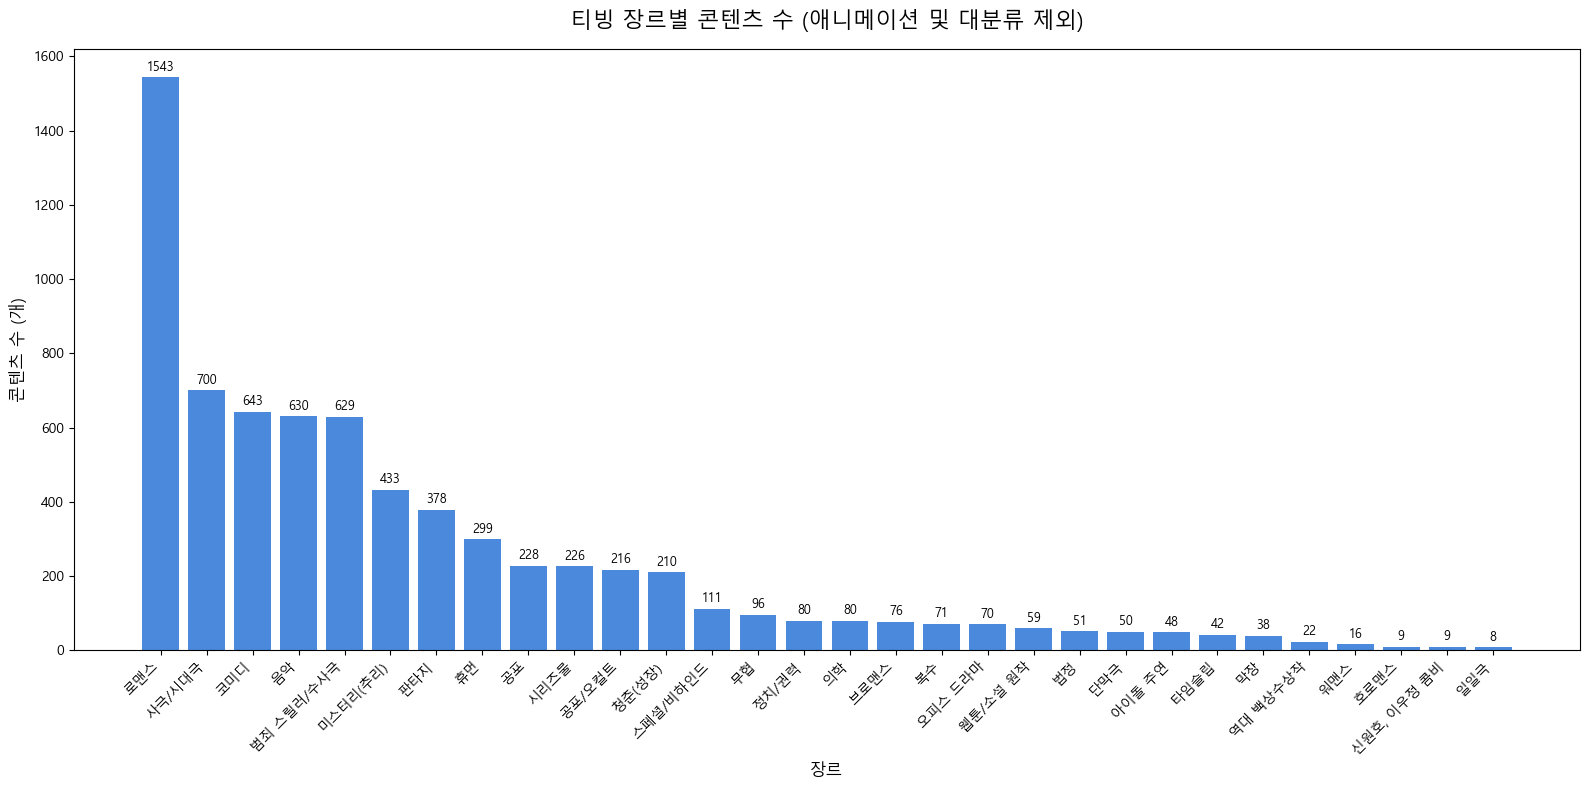

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 한글 폰트 설정 (깨짐 방지)
# 윈도우 환경
plt.rc('font', family='Malgun Gothic') 
# Mac 환경인 경우 아래 주석을 해제하고 위 코드를 주석 처리하세요.
# plt.rc('font', family='AppleGothic')

plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기
file_path = 'tving_full_data_PCA.csv'
df = pd.read_csv(file_path)

# 3. '전체(실사콘텐츠)'와 '애니메이션' 제외하기
# 데이터 상에 '전체'라는 정확한 명칭이 없을 수 있으나, 가장 큰 범주인 '실사콘텐츠'를 함께 제외합니다.
exclude_list = ['전체', '애니메이션', '실사콘텐츠'] 
df_filtered = df[~df['Genre'].isin(exclude_list)]

# 4. 데이터 정렬 (콘텐츠 수가 많은 순으로 내림차순)
df_filtered = df_filtered.sort_values(by='Content_Count', ascending=False)

# 5. 막대그래프 그리기
plt.figure(figsize=(16, 8)) # 장르가 많으므로 가로로 넓게 설정
bars = plt.bar(df_filtered['Genre'], df_filtered['Content_Count'], color='#4B89DC')

# 축 라벨 및 타이틀 설정
plt.ylabel('콘텐츠 수 (개)', fontsize=12)
plt.xlabel('장르', fontsize=12)
plt.title('티빙 장르별 콘텐츠 수 (애니메이션 및 대분류 제외)', fontsize=16, pad=15)

# x축 라벨(장르명)이 겹치지 않도록 45도 기울이기
plt.xticks(rotation=45, ha='right', fontsize=10)

# 막대 그래프 꼭대기에 정확한 수치 텍스트 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 10, # 막대 살짝 위(+10)에 텍스트 배치
             f'{int(height)}', 
             ha='center', va='bottom', fontsize=9)

# 여백 자동 조정 (글씨가 잘리지 않도록)
plt.tight_layout()
plt.show()

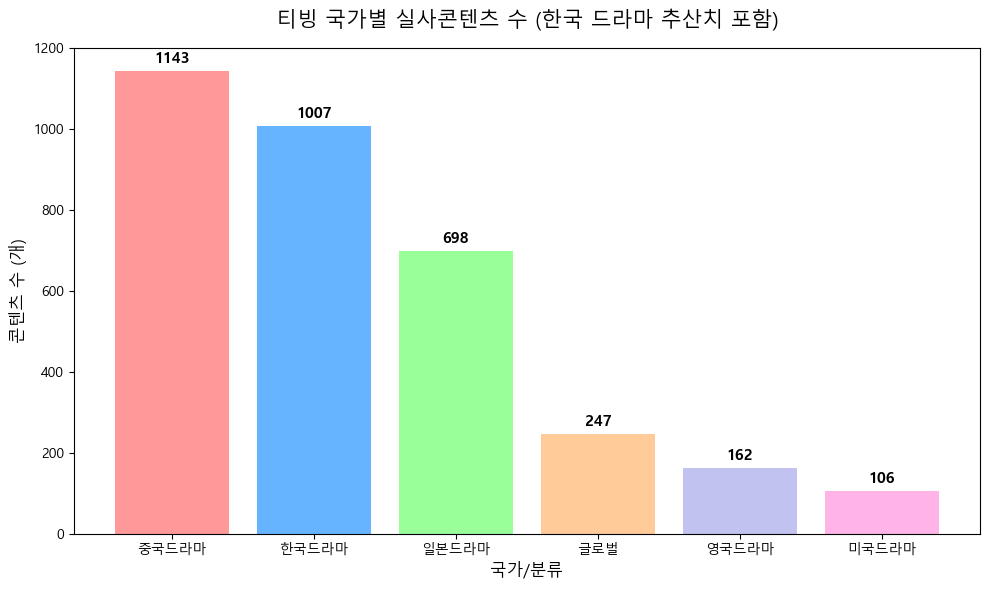

전체 실사콘텐츠: 3363개
해외 콘텐츠 합계: 2356개
추산된 한국드라마: 1007개


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 한글 폰트 설정 (깨짐 방지)
# 윈도우 환경인 경우
plt.rc('font', family='Malgun Gothic') 
# Mac 환경인 경우 아래 주석을 해제하고 위 코드를 주석 처리하세요.
# plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기
file_path = 'tving_country_data_POS.csv'
df = pd.read_csv(file_path)

# 3. 데이터 추출 및 한국 드라마 수 계산
# '실사콘텐츠' 전체 수 추출
total_live_action = df.loc[df['Genre'] == '실사콘텐츠', 'Content_Count'].values[0]

# 명시된 해외 콘텐츠 장르 리스트
foreign_genres = ['중국드라마', '일본드라마', '글로벌', '영국드라마', '미국드라마']
df_foreign = df[df['Genre'].isin(foreign_genres)].copy()

# 해외 콘텐츠 총합 계산
total_foreign = df_foreign['Content_Count'].sum()

# 한국 드라마 수 계산 (실사콘텐츠 총합 - 해외 콘텐츠 총합)
korean_drama_count = total_live_action - total_foreign

# 4. 그래프용 새로운 데이터프레임 생성
new_row = pd.DataFrame({'Genre': ['한국드라마'], 'Content_Count': [korean_drama_count]})
df_plot = pd.concat([new_row, df_foreign], ignore_index=True)

# 콘텐츠 수가 많은 순서대로 내림차순 정렬
df_plot = df_plot.sort_values(by='Content_Count', ascending=False)

# 5. 막대그래프 그리기
plt.figure(figsize=(10, 6))
# 막대 색상을 다양하게 주어 구분하기 쉽게 설정
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6']
bars = plt.bar(df_plot['Genre'], df_plot['Content_Count'], color=colors[:len(df_plot)])

# 축 라벨 및 타이틀 설정
plt.ylabel('콘텐츠 수 (개)', fontsize=12)
plt.xlabel('국가/분류', fontsize=12)
plt.title('티빙 국가별 실사콘텐츠 수 (한국 드라마 추산치 포함)', fontsize=15, pad=15)

# 막대 그래프 꼭대기에 정확한 수치 텍스트 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 10, 
             f'{int(height)}', 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# (참고용) 계산된 수치 출력
print(f"전체 실사콘텐츠: {total_live_action}개")
print(f"해외 콘텐츠 합계: {total_foreign}개")
print(f"추산된 한국드라마: {korean_drama_count}개")

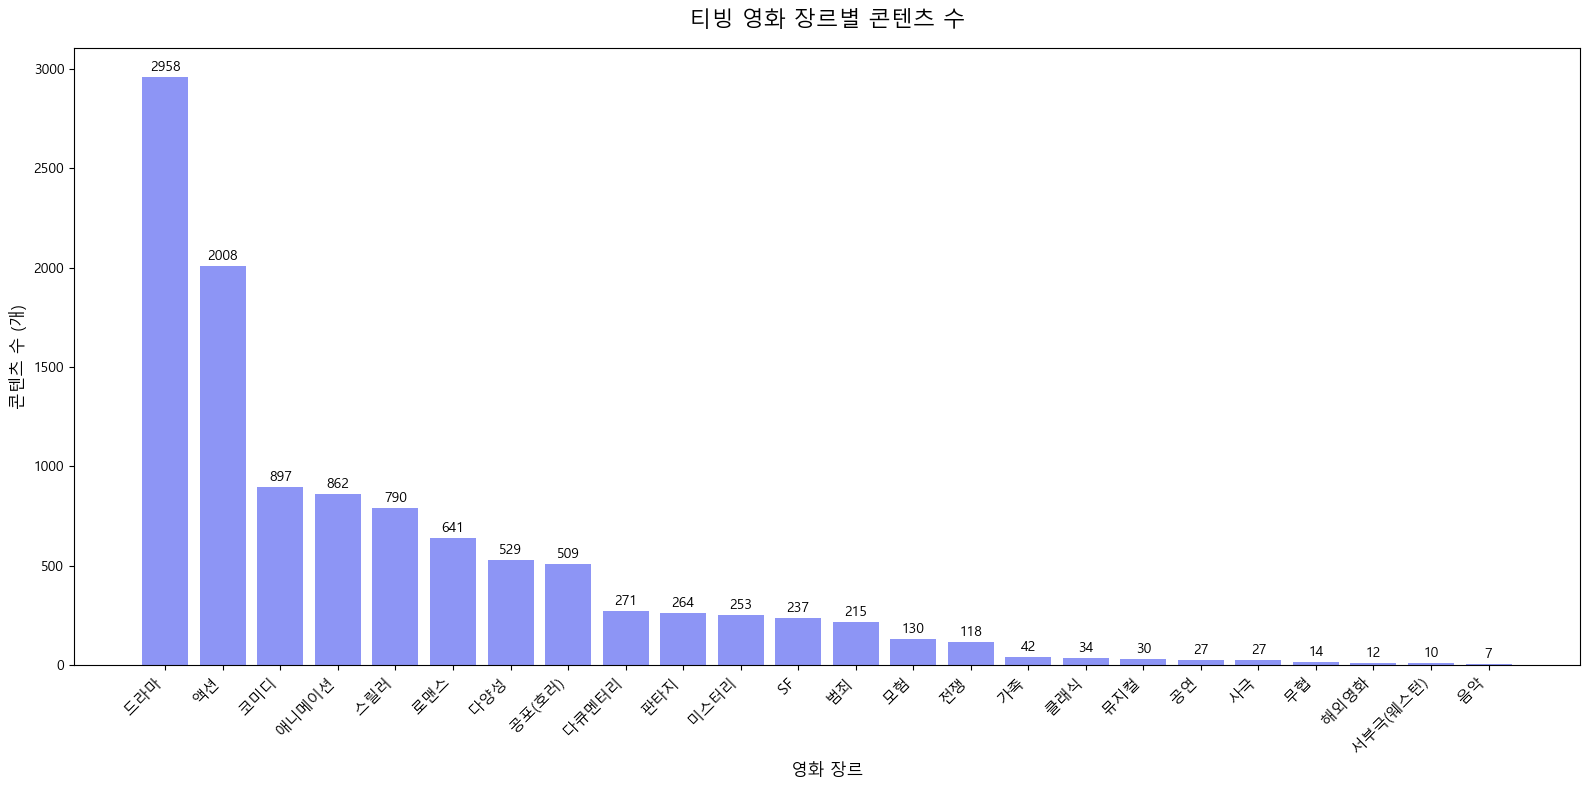

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 한글 폰트 설정 (깨짐 방지)
# 윈도우 환경인 경우
plt.rc('font', family='Malgun Gothic') 
# Mac 환경인 경우 아래 주석을 해제하고 위 코드를 주석 처리하세요.
# plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기
file_path = 'tving_movie_data_MG.csv'
df = pd.read_csv(file_path)

# 3. 데이터 정렬 (콘텐츠 수가 많은 순으로 내림차순)
df = df.sort_values(by='Content_Count', ascending=False)

# 4. 막대그래프 그리기
plt.figure(figsize=(16, 8)) # 장르가 많아 가로로 넓게 설정
bars = plt.bar(df['Genre'], df['Content_Count'], color='#8D95F5') # 예쁜 연보라/파란색 톤

# 5. 축 라벨 및 타이틀 설정
plt.ylabel('콘텐츠 수 (개)', fontsize=12)
plt.xlabel('영화 장르', fontsize=12)
plt.title('티빙 영화 장르별 콘텐츠 수', fontsize=16, pad=15)

# 6. x축 라벨(장르명)이 겹치지 않도록 45도 기울이기
plt.xticks(rotation=45, ha='right', fontsize=11)

# 7. 막대 그래프 꼭대기에 정확한 수치 텍스트 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 15, 
             f'{int(height)}', 
             ha='center', va='bottom', fontsize=10)

# 8. 여백 자동 조정 및 출력
plt.tight_layout()
plt.show()

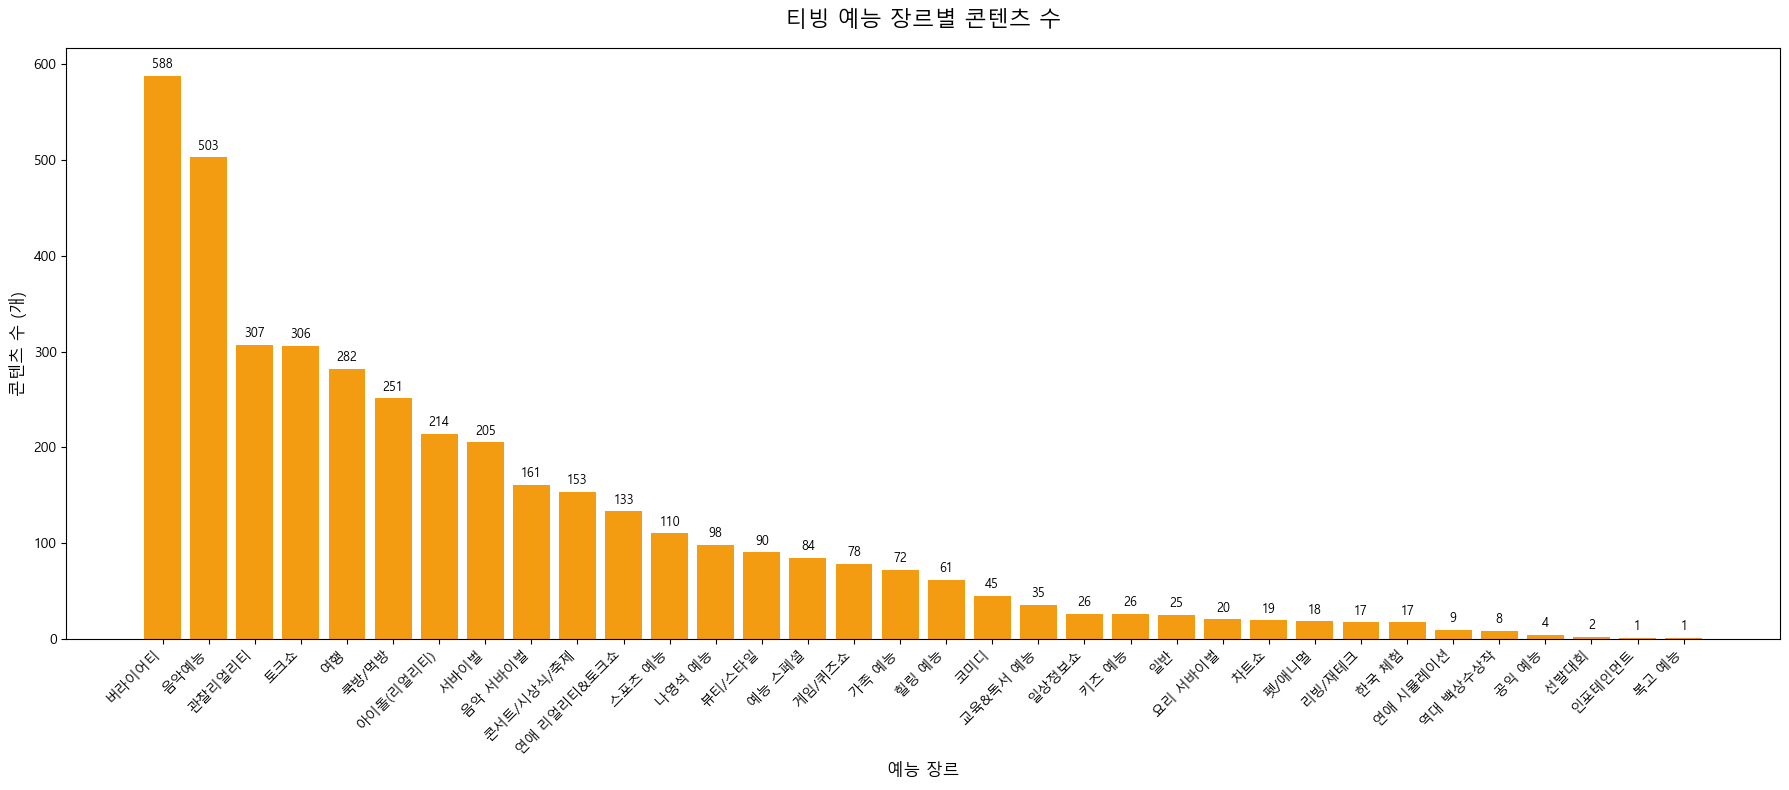

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 한글 폰트 설정 (깨짐 방지)
# 윈도우 환경인 경우
plt.rc('font', family='Malgun Gothic') 
# Mac 환경인 경우 아래 주석을 해제하고 위 코드를 주석 처리하세요.
# plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기
file_path = 'tving_entertainment_data_PCD.csv'
df = pd.read_csv(file_path)

# 3. 데이터 정렬 (콘텐츠 수가 많은 순으로 내림차순)
df = df.sort_values(by='Content_Count', ascending=False)

# 4. 막대그래프 그리기
# 장르 종류가 많으므로 그래프의 가로 길이를 여유 있게 설정합니다.
plt.figure(figsize=(18, 8)) 
bars = plt.bar(df['Genre'], df['Content_Count'], color='#F39C12') # 예능과 어울리는 오렌지/옐로우 톤

# 5. 축 라벨 및 타이틀 설정
plt.ylabel('콘텐츠 수 (개)', fontsize=12)
plt.xlabel('예능 장르', fontsize=12)
plt.title('티빙 예능 장르별 콘텐츠 수', fontsize=16, pad=15)

# 6. x축 라벨(장르명)이 겹치지 않도록 45도 기울이기
plt.xticks(rotation=45, ha='right', fontsize=10)

# 7. 막대 그래프 꼭대기에 정확한 수치 텍스트 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,  # 막대 살짝 위(+5)에 표시
             f'{int(height)}', 
             ha='center', va='bottom', fontsize=9)

# 8. 여백 자동 조정 및 출력
plt.tight_layout()
plt.show()